# 1,84 km al año. Esa es la velocidad

a la que tendría que moverse una planta hacia el norte —cada año, durante 80 años— para mantener su clima actual en el peor escenario de emisiones. La mayoría no puede.

**Paper:** [Climate-induced range shifts support local plant diversity but don't reduce extinction risk](https://doi.org/10.1126/science.aea1676)
*Science · 2026-05-07*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-10-rango-plantas-clima-extincion/notebook.ipynb)

> Este notebook explora los datos del paper sin opinar sobre ellos. Las cifras son del paper o derivadas de los datos abiertos en Zenodo.

## Contexto

El paper combina **BioShifts** (14.488 observaciones de cambios de rango en 6.579 especies de plantas) con 6,8 millones de registros de ocurrencia, dos modelos de hábitat y proyecciones de 10 modelos climáticos globales. El resultado: hábitats actuales y futuros en cuadrículas de 8 × 8 km para cada especie, bajo cuatro escenarios de emisiones para 2081–2100.

Este notebook usa los datos agregados que el equipo publicó en Zenodo y mira tres preguntas:

1. ¿Cuán rápido se proyecta que migren las plantas, y cómo cambia eso entre escenarios?
2. ¿Qué tipos de plantas migran más rápido —y cuáles se quedan atrás?
3. ¿Qué relación hay entre la edad a la que una planta llega a madurez y su capacidad proyectada de moverse?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESCENARIO_BAJO = 13          # Escenario con menor velocidad mediana
ESCENARIO_ALTO = 4           # Escenario con mayor velocidad mediana
FUENTE = 'Fuente: Wang et al. (2026), Science | Datos: Zenodo 17427091'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_VIOLETA = '#7C3AED'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en repo → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Carga
DATOS = 'datos'
sc = pd.read_csv(f'{DATOS}/shift_por_escenario.csv')
gf = pd.read_csv(f'{DATOS}/shift_por_growth_form.csv')
am = pd.read_csv(f'{DATOS}/shift_por_edad_madurez.csv')
sample = pd.read_csv(f'{DATOS}/shift_rate_sample.csv')

# Resumen
print(f'Escenarios climáticos: {len(sc)} (4 emisiones × 4 percentiles GCM)')
print(f'Especies por escenario: {int(sc["n_species"].iloc[0]):,}')
print(f'Formas de crecimiento: {len(gf)} ({", ".join(gf["GF"])})')
print(f'Sample para distribuciones: {len(sample):,} filas (especie × dispersal × escenario)')
print()
print(f'Velocidad latitudinal mediana — escenario {ESCENARIO_BAJO}: {sc[sc.scenario==ESCENARIO_BAJO].lat_median.iloc[0]:.3f} km/año')
print(f'Velocidad latitudinal mediana — escenario {ESCENARIO_ALTO}: {sc[sc.scenario==ESCENARIO_ALTO].lat_median.iloc[0]:.3f} km/año')


Escenarios climáticos: 16 (4 emisiones × 4 percentiles GCM)
Especies por escenario: 62,416
Formas de crecimiento: 6 (Herb, Shrub, Tree, Epiphyte, Grass, Succulent)
Sample para distribuciones: 10,000 filas (especie × dispersal × escenario)

Velocidad latitudinal mediana — escenario 13: 0.043 km/año
Velocidad latitudinal mediana — escenario 4: 1.840 km/año


Aquí está.

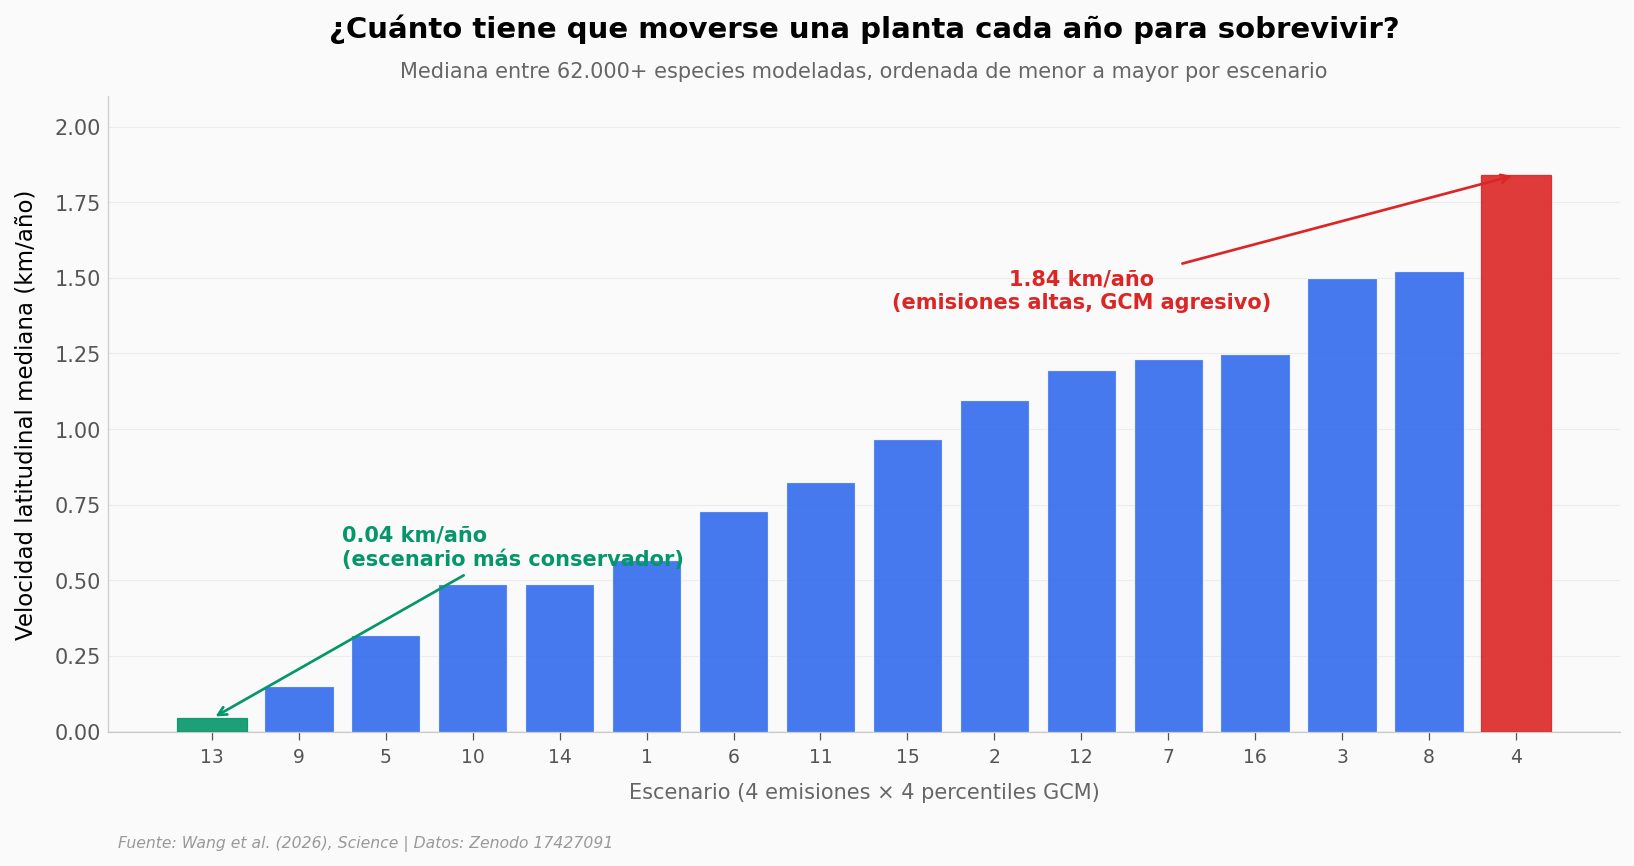

In [2]:
sc_sorted = sc.sort_values('lat_median').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
positions = np.arange(len(sc_sorted))

bars = ax.bar(positions, sc_sorted['lat_median'],
              color=COLOR_DATOS, alpha=0.85,
              edgecolor='white', linewidth=0.6, zorder=3)

# Marcar el más bajo y el más alto en rojo
bars[0].set_color(COLOR_SECUNDARIO)
bars[0].set_alpha(0.9)
bars[-1].set_color(COLOR_ALERTA)
bars[-1].set_alpha(0.9)

# Anotaciones
ymin = sc_sorted['lat_median'].iloc[0]
ymax = sc_sorted['lat_median'].iloc[-1]
ax.annotate(f'{ymin:.2f} km/año\n(escenario más conservador)',
            xy=(0, ymin), xytext=(1.5, 0.55),
            fontsize=10, color=COLOR_SECUNDARIO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_SECUNDARIO, lw=1.3))
ax.annotate(f'{ymax:.2f} km/año\n(emisiones altas, GCM agresivo)',
            xy=(len(sc_sorted)-1, ymax), xytext=(10, 1.4),
            fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

ax.set_xticks(positions)
ax.set_xticklabels(sc_sorted['scenario'].astype(str), fontsize=9)
ax.set_xlabel('Escenario (4 emisiones × 4 percentiles GCM)', fontsize=10, color='#666666')
ax.set_ylabel('Velocidad latitudinal mediana (km/año)', fontsize=11)
ax.set_title('¿Cuánto tiene que moverse una planta cada año para sobrevivir?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Mediana entre 62.000+ especies modeladas, ordenada de menor a mayor por escenario',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 2.1)
ax.axhline(y=0, color='#999999', linewidth=0.6)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/01_velocidad_por_escenario.png', dpi=200, bbox_inches='tight')
plt.show()


La velocidad mediana proyectada va de **0,04 a 1,84 km/año** —un factor de 42 entre el escenario más benigno y el más severo. La distancia entre los escenarios más probables (los del centro) y el peor crece rápidamente: pasar del escenario 1 (0,57 km/año) al 4 (1,84 km/año) requiere multiplicar la velocidad de migración por 3,2.

Una velocidad mediana de 1,84 km/año implica que la mediana de las especies modeladas tendría que recorrer **~150 km hacia el norte** para 2100 sólo para mantener su clima actual. Algunas pueden hacerlo. Muchas no.

## ¿Qué plantas migran más rápido?

El equipo proyectó shift rate por forma de crecimiento. Aquí la mediana entre escenarios para cada grupo, ordenada de más lento a más rápido.

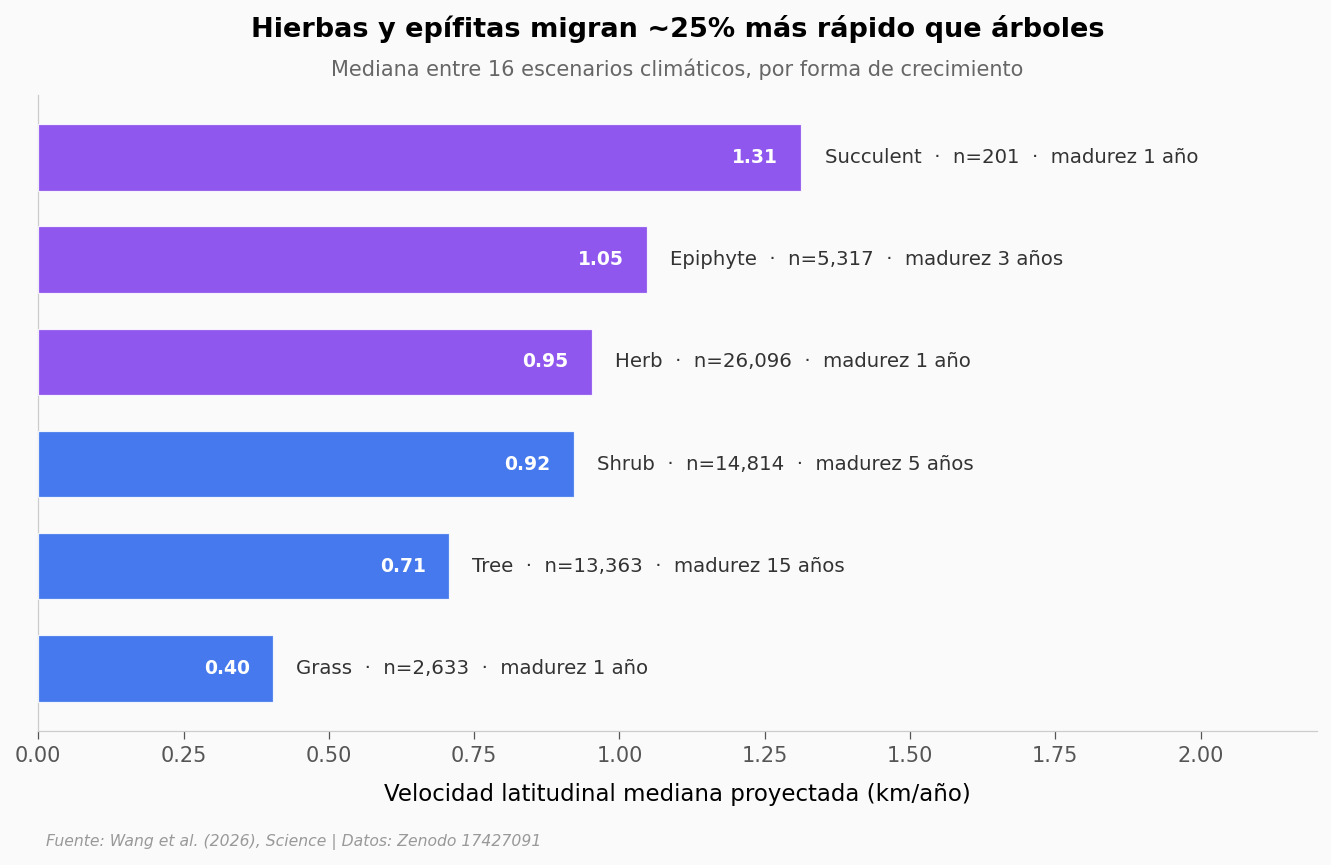

In [3]:
gf_sorted = gf.sort_values('lat_median').reset_index(drop=True)

# Color por velocidad: los más rápidos en violeta, los lentos en gris-azul
colors_gf = [COLOR_DATOS, COLOR_DATOS, COLOR_DATOS, COLOR_VIOLETA, COLOR_VIOLETA, COLOR_VIOLETA]

fig, ax = plt.subplots(figsize=(11, 5.5))
positions = np.arange(len(gf_sorted))

# Barras horizontales con IQR como error bar (q25 → q75)
ax.barh(positions, gf_sorted['lat_median'],
        color=colors_gf, alpha=0.85, edgecolor='white', linewidth=0.6, zorder=3,
        height=0.65)

# Inline labels: nombre + n_species + edad madurez
for i, row in gf_sorted.iterrows():
    label = f"{row['GF']}  ·  n={int(row['n_species']):,}  ·  madurez {row['age_mat_median']:.0f} año{'s' if row['age_mat_median']!=1 else ''}"
    ax.text(row['lat_median'] + 0.04, i, label,
            fontsize=9.5, va='center', color='#333333')
    # Valor numérico al final de la barra
    ax.text(row['lat_median'] - 0.04, i, f"{row['lat_median']:.2f}",
            fontsize=9, va='center', ha='right', color='white', fontweight='bold')

ax.set_yticks([])
ax.set_xlim(0, 2.2)
ax.set_xlabel('Velocidad latitudinal mediana proyectada (km/año)', fontsize=11)
ax.set_title('Hierbas y epífitas migran ~25% más rápido que árboles',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Mediana entre 16 escenarios climáticos, por forma de crecimiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_velocidad_por_forma.png', dpi=200, bbox_inches='tight')
plt.show()


La diferencia entre árboles (0,71 km/año) y hierbas (0,95 km/año) es de **26%**. La pista del porqué está en la última columna de la gráfica: los árboles llegan a madurez reproductiva con una mediana de **15 años**; las hierbas, con **1 año**.

Una planta que tarda 15 años en producir su primera semilla tiene 15× menos turnos que una hierba para que el viento, un pájaro o un mamífero lleve esa semilla a un lugar donde el clima todavía sirva. El modelo recoge ese trade-off.

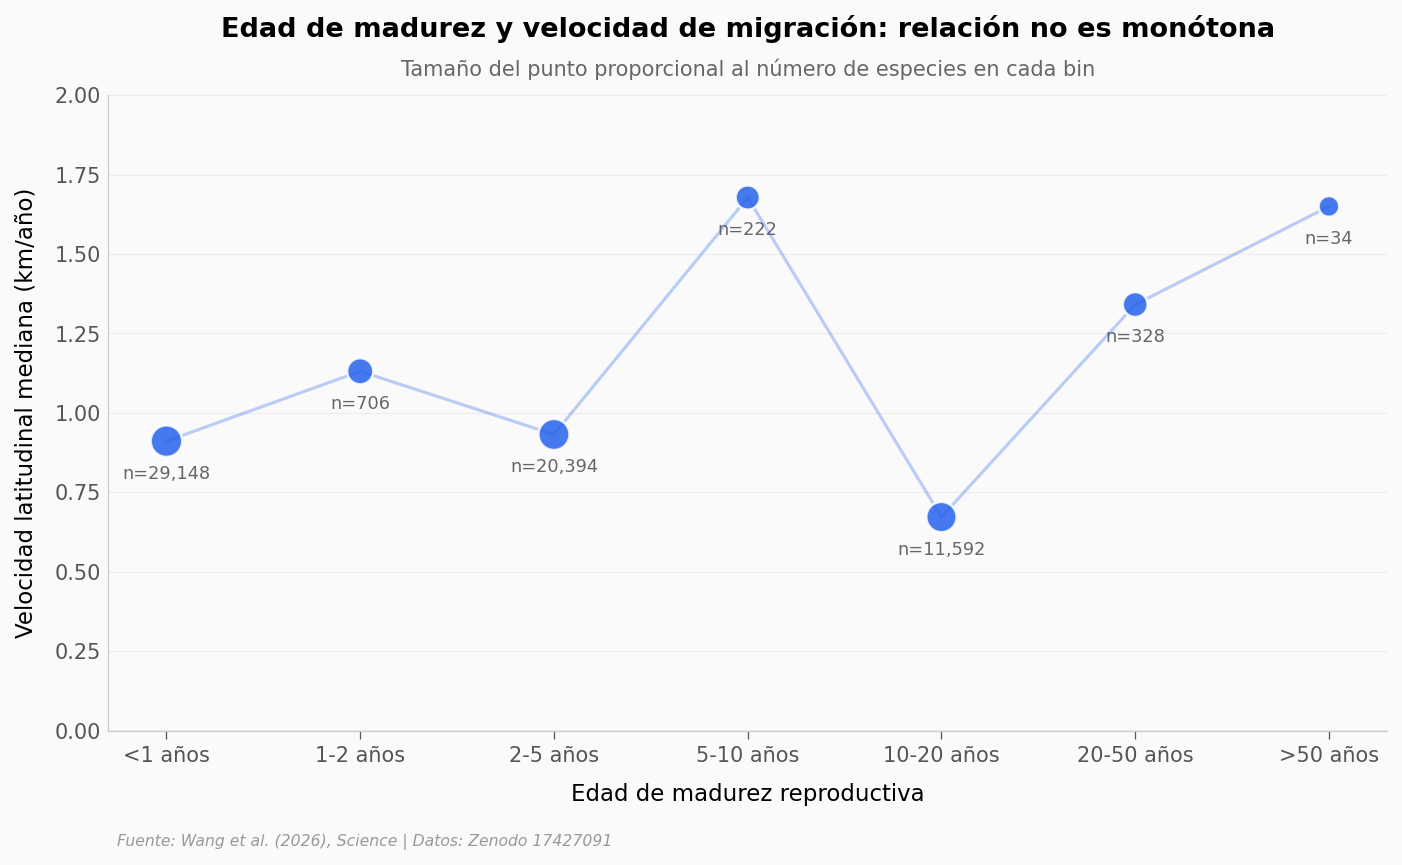

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Ordenar bins por orden lógico (no alfabético)
order = ['<1', '1-2', '2-5', '5-10', '10-20', '20-50', '>50']
am_sorted = am.set_index('age_bin').loc[order].reset_index()

# Tamaño del punto = log(n_species) escalado
sizes = 30 + 200 * np.log10(am_sorted['n_species']) / np.log10(am_sorted['n_species'].max())

scatter = ax.scatter(np.arange(len(am_sorted)), am_sorted['lat_median'],
                     s=sizes, c=COLOR_DATOS, alpha=0.85,
                     edgecolors='white', linewidths=1.2, zorder=5)

# Línea conectando puntos (tendencia visual)
ax.plot(np.arange(len(am_sorted)), am_sorted['lat_median'],
        color=COLOR_DATOS, alpha=0.3, linewidth=1.5, zorder=4)

# Anotaciones de n
for i, row in am_sorted.iterrows():
    ax.annotate(f"n={int(row['n_species']):,}",
                xy=(i, row['lat_median']), xytext=(0, -18),
                textcoords='offset points', fontsize=8.5,
                color='#666666', ha='center')

ax.set_xticks(np.arange(len(am_sorted)))
ax.set_xticklabels([f'{x} años' for x in am_sorted['age_bin']], fontsize=10)
ax.set_xlabel('Edad de madurez reproductiva', fontsize=11)
ax.set_ylabel('Velocidad latitudinal mediana (km/año)', fontsize=11)
ax.set_title('Edad de madurez y velocidad de migración: relación no es monótona',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Tamaño del punto proporcional al número de especies en cada bin',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 2.0)
ax.axhline(y=0, color='#999999', linewidth=0.6)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_edad_madurez.png', dpi=200, bbox_inches='tight')
plt.show()


La tendencia no es lineal. Los bins con más especies (los <1, 2–5 y 10–20 años) caen cerca de 0,7–0,9 km/año; los bins con pocas especies (5–10, 20–50, >50) saltan a velocidades más altas, pero con muestras pequeñas. La señal robusta es Tree vs Herb, no este escalado fino.

## ¿Qué tan rápido es 1,84 km/año en términos de la distribución completa?

Hasta acá miramos medianas. Pero la mediana esconde dos cosas: las plantas que **tendrían que moverse en sentido contrario** (Lat50 negativo) y las que el modelo proyecta moverse mucho más rápido o más lento que el promedio.

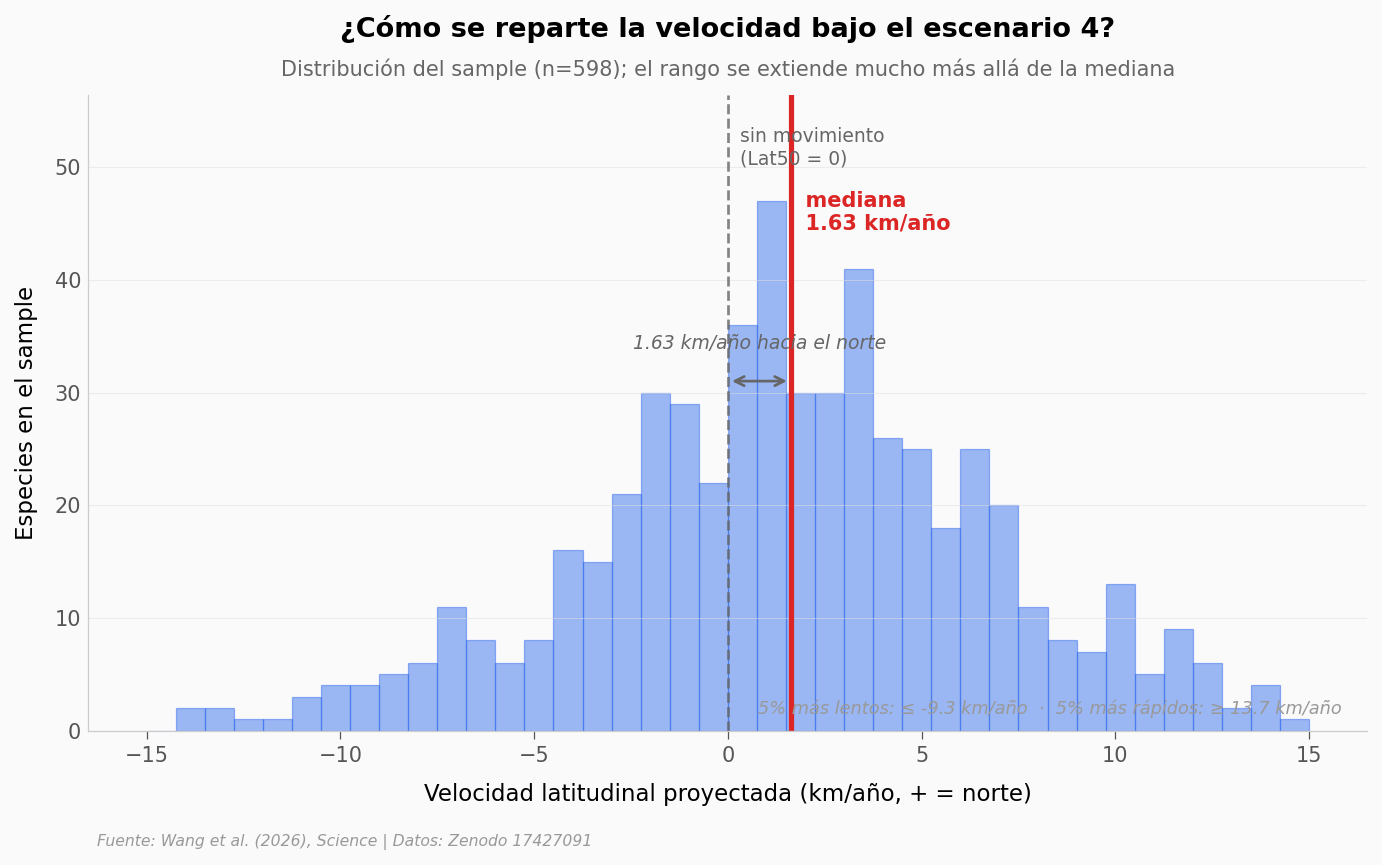

In [5]:
# Distribución de velocidades para el escenario más severo (4) en el sample
sample_alto = sample[sample['scenario'] == ESCENARIO_ALTO]['Lat50']
mediana_alto = sample_alto.median()

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, patches = ax.hist(sample_alto, bins=40, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.6, range=(-15, 15))
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea en 0 (sin movimiento)
ax.axvline(x=0, color='#666666', linewidth=1.3, linestyle='--', alpha=0.8)
ax.text(0, y_max * 0.95, '  sin movimiento\n  (Lat50 = 0)',
        fontsize=9, color='#666666', va='top')

# Línea en la mediana del escenario alto
ax.axvline(x=mediana_alto, color=COLOR_ALERTA, linewidth=2.5)
ax.text(mediana_alto, y_max * 0.85, f'  mediana\n  {mediana_alto:.2f} km/año',
        fontsize=10, color=COLOR_ALERTA, va='top', fontweight='bold')

# Flecha mostrando el desplazamiento desde 0 hasta la mediana
ax.annotate('', xy=(mediana_alto, y_max * 0.55), xytext=(0, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.3))
ax.text(mediana_alto / 2, y_max * 0.60,
        f'{mediana_alto:.2f} km/año hacia el norte',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('Velocidad latitudinal proyectada (km/año, + = norte)', fontsize=11)
ax.set_ylabel('Especies en el sample', fontsize=11)
ax.set_title(f'¿Cómo se reparte la velocidad bajo el escenario {ESCENARIO_ALTO}?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución del sample (n={len(sample_alto):,}); el rango se extiende mucho más allá de la mediana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Cola larga
q05, q95 = sample_alto.quantile([0.05, 0.95]).values
ax.text(0.98, 0.02,
        f'5% más lentos: ≤ {q05:.1f} km/año  ·  5% más rápidos: ≥ {q95:.1f} km/año',
        transform=ax.transAxes, fontsize=8.5, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_distribucion_escenario_alto.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La velocidad mediana proyectada va de 0,04 a 1,84 km/año entre escenarios | ✅ | `shift_por_escenario.csv`: scenario 13 = 0,043 km/año, scenario 4 = 1,840 km/año (factor 42×) |
| El escenario más severo requiere ~3,2× más velocidad que un escenario moderado | ✅ | 1,840 / 0,568 = 3,24 (scenario 4 vs scenario 1) |
| Los árboles migran ~26% más lento que las hierbas | ✅ | Tree mediana 0,707 vs Herb 0,952 km/año; gap = (0,952−0,707)/0,952 = 25,7% |
| El modelo cubre 67.664 especies modeladas (más que las 6.579 del entrenamiento) | ✅ | 67.664 únicas en `predict_shift_rate2025.csv`; el paper reporta 18% de plantas vasculares conocidas |
| 7–16% de las especies se proyectan a perder >90% de su rango | ⚠️ | Cifra del abstract; no recalculada en este notebook (requiere los rasters originales de 142 MB) |
| 70–80% de la pérdida proyectada viene de pérdida de hábitat, no de límites de dispersión | ⚠️ | Cifra del abstract; el modelo lo atribuye a este mecanismo, no es una observación |

> **Limitaciones:** los datos de Zenodo son **agregados** del modelo, no proyecciones por celda. El sample de 10.000 filas es suficiente para distribuciones, pero no para reconstruir los mapas espaciales del paper. Toda cifra sobre 2081–2100 es una **proyección del modelo**, no una observación; la conclusión del abstract —*"es poco probable que las migraciones eviten extinciones globales"*— sale del mismo modelo y descansa en supuestos sobre límites de dispersión y pérdida de hábitat que el paper detalla en sus apéndices.

## Ahora tú

1. **¿Cuál es el modo de dispersión más rápido?** Pista: agrupa `shift_por_dispersal_escenario.csv` por `disp` y mira la mediana de `lat_median`.
2. **¿Cuántas especies del sample tienen Lat50 negativo (migrarían hacia el sur o no migran)?** Pista: filtra el sample y cuenta.
3. **¿La velocidad altitudinal (m/año) cambia tanto entre escenarios como la latitudinal (km/año)?** Pista: usa `ele_median` en `sc` y compara el ratio max/min con el de `lat_median`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Qué modo de dispersión es el más rápido?
disp = pd.read_csv(f'{DATOS}/shift_por_dispersal_escenario.csv')
ranking = (disp.groupby('disp')['lat_median']
              .median()
              .sort_values(ascending=False)
              .round(3))
print('Velocidad latitudinal mediana por modo de dispersión (km/año):')
print('─' * 50)
for modo, vel in ranking.items():
    barra = '█' * int(vel * 8)
    print(f'  {modo:12s} {vel:5.2f}  {barra}')
print()
print('Anemochor = viento, Zoochor = animales, Hemerochor = humanos,')
print('Autochor = autónomo, Nautochor = agua, Chamaechor/Ombrochor = otros mecanismos')


Velocidad latitudinal mediana por modo de dispersión (km/año):
──────────────────────────────────────────────────
  Ombrochor     1.17  █████████
  Anemochor     1.06  ████████
  Autochor      0.94  ███████
  Hemerochor    0.71  █████
  Zoochor       0.71  █████
  Nautochor     0.65  █████
  Chamaechor    0.29  ██

Anemochor = viento, Zoochor = animales, Hemerochor = humanos,
Autochor = autónomo, Nautochor = agua, Chamaechor/Ombrochor = otros mecanismos


## Créditos

**Paper original:** Wang et al. (2026). [Climate-induced range shifts support local plant diversity but don't reduce extinction risk](https://doi.org/10.1126/science.aea1676). *Science*, 2026-05-07.

**Datos:** Zenodo records [17427091](https://doi.org/10.5281/zenodo.17427091) (datos) y [17430299](https://doi.org/10.5281/zenodo.17430299) (código). CC-BY 4.0.

**Repositorio del notebook:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0.

## Fuentes

**Paper**: [Climate-induced range shifts support local plant diversity but don't reduce extinction risk](https://doi.org/10.1126/science.aea1676)  
*Science, 2026-05-07*

**Datos**: [Data for: Climate-induced range shifts will support local plant diversity but not reduce extinction risk (record 17427092)](https://doi.org/10.5281/zenodo.17427091)

*16 afirmaciones verificadas contra estas fuentes*